#PHÂN LOẠI CÁC NHÃN TOKEN CỦA CÁC NHẬN ĐỊNH ĐỀ THI THPT MÔN TOÁN

## 1. Cài thư viện

In [127]:
!pip install sklearn-crfsuite seqeval tensorflow seaborn -q

## 2. Import thư viện

In [128]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics
from seqeval.metrics import classification_report as seqeval_classification_report
from seqeval.metrics import f1_score as seqeval_f1_score

try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed, Bidirectional
    print("Đang dùng tensorflow.keras")
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    print("Không import được tensorflow.keras, chuyển sang keras fallback")
    print("Chi tiết lỗi:", e)

    from keras.preprocessing.sequence import pad_sequences
    from keras.utils import to_categorical
    from keras.models import Sequential
    from keras.layers import Embedding, LSTM, Dense, TimeDistributed, Bidirectional

    print("Đang dùng keras fallback")

Đang dùng tensorflow.keras
TensorFlow version: 2.20.0


## 3. Upload file

In [129]:
from google.colab import files
uploaded = files.upload()

Saving Data_TienXuLy_POS_NER.tsv to Data_TienXuLy_POS_NER.tsv


In [130]:
def read_tsv_dataset(file_path):
    sentences = []
    current_sentence = []

    with open(file_path, "r", encoding="utf-8-sig") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue

            parts = line.split("\t")
            if len(parts) != 3:
                print(f"Dòng lỗi định dạng tại line {line_num}: {line}")
                continue

            token, pos_tag, ner_tag = parts
            current_sentence.append({
                "token": token,
                "pos": pos_tag,
                "ner": ner_tag
            })

    if current_sentence:
        sentences.append(current_sentence)

    return sentences

sentences = read_tsv_dataset("Data_TienXuLy_POS_NER.tsv")
print("Số câu:", len(sentences))
print("Ví dụ:", sentences[0][:5] if len(sentences) > 0 else [])

Số câu: 330
Ví dụ: [{'token': 'Đề_thi', 'pos': 'N', 'ner': 'O'}, {'token': 'rất', 'pos': 'R', 'ner': 'B-LEVEL'}, {'token': 'khó', 'pos': 'A', 'ner': 'I-LEVEL'}, {'token': '.', 'pos': 'CH', 'ner': 'O'}]


## 4. Báo cáo dữ liệu

### 4.1. Một số thông số cơ bản

In [131]:
num_sentences = len(sentences)
num_tokens = sum(len(sent) for sent in sentences)
sentence_lengths = [len(sent) for sent in sentences]

pos_counter = Counter()
ner_counter = Counter()
token_counter = Counter()

for sent in sentences:
    for item in sent:
        pos_counter[item["pos"]] += 1
        ner_counter[item["ner"]] += 1
        token_counter[item["token"]] += 1

print("===== THỐNG KÊ CƠ BẢN =====")
print("Số câu:", num_sentences)
print("Tổng số token:", num_tokens)
print("Độ dài câu trung bình:", np.mean(sentence_lengths))
print("Độ dài câu ngắn nhất:", np.min(sentence_lengths))
print("Độ dài câu dài nhất:", np.max(sentence_lengths))

print("\n===== POS TAGS =====")
for tag, count in pos_counter.most_common():
    print(f"{tag}: {count}")

print("\n===== NER TAGS =====")
for tag, count in ner_counter.most_common():
    print(f"{tag}: {count}")

print("\n===== TOP 20 TOKENS =====")
for tok, count in token_counter.most_common(20):
    print(f"{tok}: {count}")

===== THỐNG KÊ CƠ BẢN =====
Số câu: 330
Tổng số token: 4510
Độ dài câu trung bình: 13.666666666666666
Độ dài câu ngắn nhất: 3
Độ dài câu dài nhất: 64

===== POS TAGS =====
N: 1890
V: 655
A: 524
CH: 482
Cc: 232
R: 210
E: 201
M: 175
L: 80
C: 44
P: 17

===== NER TAGS =====
O: 2424
B-LEVEL: 377
I-LEVEL: 344
B-STRUC: 229
I-STRUC: 219
I-DISC: 214
B-DISC: 160
I-YEAR: 158
B-YEAR: 152
B-SKILL: 119
I-SKILL: 114

===== TOP 20 TOKENS =====
.: 326
Đề_thi: 238
và: 216
có: 169
khó: 156
,: 155
phân_hóa: 119
năm: 104
độ: 94
câu: 78
cao: 74
đề_thi: 60
với: 55
ở: 53
tính: 51
thí_sinh: 48
khá: 46
Năm: 42
Toán: 42
nhiều: 41


### 4.2. Biểu đồ histogram phân bố

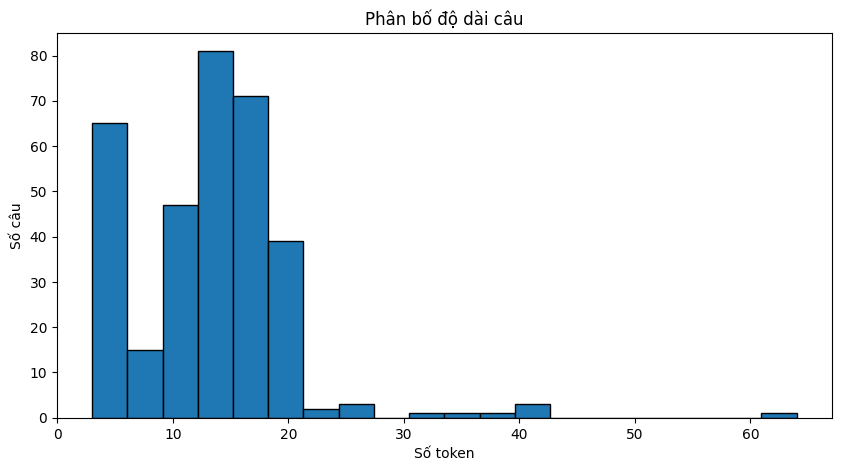

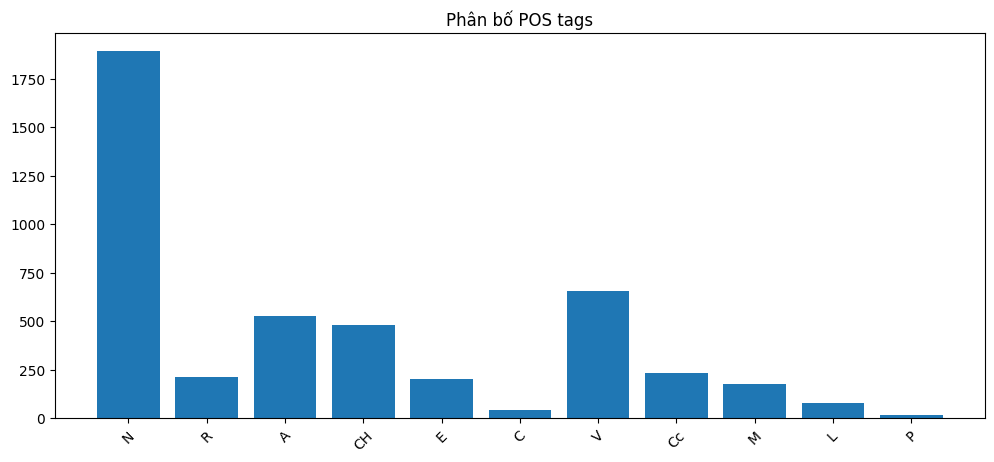

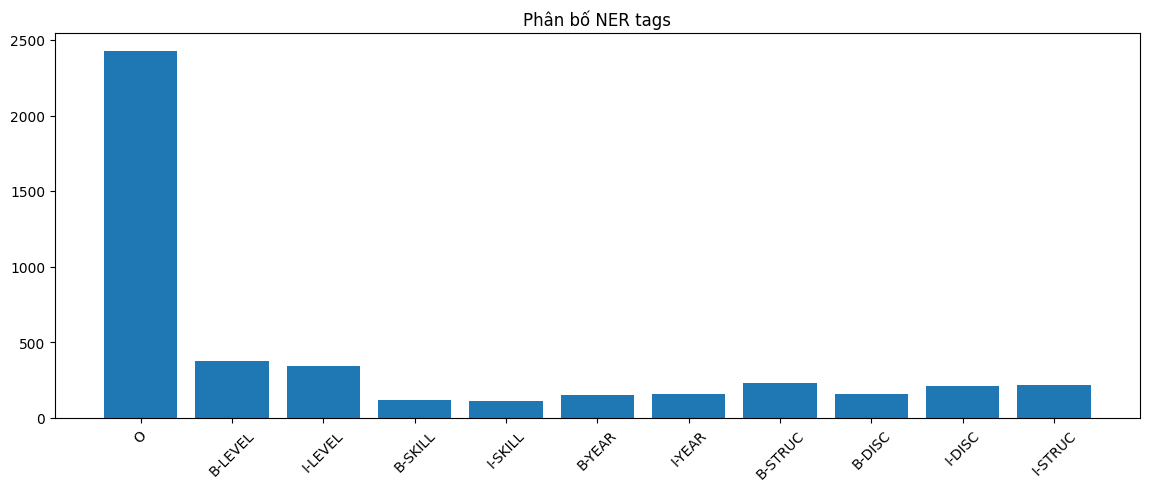

In [132]:
plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=20, edgecolor="black")
plt.title("Phân bố độ dài câu")
plt.xlabel("Số token")
plt.ylabel("Số câu")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(pos_counter.keys(), pos_counter.values())
plt.title("Phân bố POS tags")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(ner_counter.keys(), ner_counter.values())
plt.title("Phân bố NER tags")
plt.xticks(rotation=45)
plt.show()

### 4.3. Kiểm tra lỗi BIO

In [133]:
def check_bio_errors(sentences):
    errors = []

    for sent_idx, sent in enumerate(sentences):
        prev_tag = "O"
        for tok_idx, item in enumerate(sent):
            tag = item["ner"]

            if tag.startswith("I-"):
                curr_type = tag[2:]

                if prev_tag == "O":
                    errors.append((sent_idx, tok_idx, item["token"], tag, "I-tag đứng sau O"))
                elif prev_tag.startswith("B-") or prev_tag.startswith("I-"):
                    prev_type = prev_tag[2:]
                    if prev_type != curr_type:
                        errors.append((sent_idx, tok_idx, item["token"], tag, "I-tag khác loại với tag trước"))

            prev_tag = tag

    return errors

bio_errors = check_bio_errors(sentences)

print("Số lỗi BIO:", len(bio_errors))
for err in bio_errors[:20]:
    print(err)

Số lỗi BIO: 0


### 4.4. Trích xuất entity

In [134]:
def extract_entities(sentence):
    entities = []
    current_tokens = []
    current_type = None

    for item in sentence:
        token = item["token"]
        tag = item["ner"]

        if tag == "O":
            if current_tokens:
                entities.append((" ".join(current_tokens), current_type))
                current_tokens = []
                current_type = None
            continue

        prefix, ent_type = tag.split("-", 1)

        if prefix == "B":
            if current_tokens:
                entities.append((" ".join(current_tokens), current_type))
            current_tokens = [token]
            current_type = ent_type

        elif prefix == "I":
            if current_tokens and current_type == ent_type:
                current_tokens.append(token)
            else:
                if current_tokens:
                    entities.append((" ".join(current_tokens), current_type))
                current_tokens = [token]
                current_type = ent_type

    if current_tokens:
        entities.append((" ".join(current_tokens), current_type))

    return entities

entity_counter = Counter()
for sent in sentences:
    for entity_text, entity_type in extract_entities(sent):
        entity_counter[entity_type] += 1

print("Số lượng entity theo loại:")
for ent_type, count in entity_counter.items():
    print(ent_type, count)

Số lượng entity theo loại:
LEVEL 377
SKILL 119
YEAR 152
STRUC 229
DISC 160


## 5. Các mô hình thuật toán:

### 5.1. Thuật toán KNN

- Tạo feature cho KNN

In [135]:
def token_features(sent, i):
    token = sent[i]["token"]
    prev_token = sent[i - 1]["token"] if i > 0 else "<BOS>"
    next_token = sent[i + 1]["token"] if i < len(sent) - 1 else "<EOS>"

    return {
        "token": token,
        "token_lower": token.lower(),
        "prefix_1": token[:1],
        "prefix_2": token[:2],
        "prefix_3": token[:3],
        "suffix_1": token[-1:],
        "suffix_2": token[-2:],
        "suffix_3": token[-3:],
        "is_digit": str(token.isdigit()),
        "has_digit": str(any(ch.isdigit() for ch in token)),
        "has_underscore": str("_" in token),
        "is_upper": str(token.isupper()),
        "len_token": str(len(token)),
        "prev_token": prev_token,
        "next_token": next_token,
        "prev_lower": prev_token.lower(),
        "next_lower": next_token.lower(),
    }

X_dict = []
y_pos_knn = []
y_ner_knn = []

for sent in sentences:
    for i in range(len(sent)):
        X_dict.append(token_features(sent, i))
        y_pos_knn.append(sent[i]["pos"])
        y_ner_knn.append(sent[i]["ner"])

vectorizer = DictVectorizer(sparse=False)
X_knn = vectorizer.fit_transform(X_dict)

print("Số token samples:", len(X_knn))
print("Số chiều feature:", X_knn.shape[1])

Số token samples: 4510
Số chiều feature: 4044


#### 5.1.1. KNN cho POS

In [136]:
X_pos_knn_train, X_pos_knn_test, y_pos_test_train, y_pos_test = train_test_split(
    X_knn, y_pos_knn, test_size=0.2, random_state=42, stratify=y_pos_knn
)

knn_pos = KNeighborsClassifier(n_neighbors=5)
knn_pos.fit(X_pos_knn_train, y_pos_test_train)
y_pos_pred = knn_pos.predict(X_pos_knn_test)

print("===== KNN POS =====")
print("Accuracy:", accuracy_score(y_pos_test, y_pos_pred))
print("Macro F1:", f1_score(y_pos_test, y_pos_pred, average="macro"))
print("Weighted F1:", f1_score(y_pos_test, y_pos_pred, average="weighted"))
print(classification_report(y_pos_test, y_pos_pred))

===== KNN POS =====
Accuracy: 0.9556541019955654
Macro F1: 0.9579838834179889
Weighted F1: 0.9558644828645058
              precision    recall  f1-score   support

           A       0.87      0.98      0.92       105
           C       1.00      1.00      1.00         9
          CH       1.00      1.00      1.00        96
          Cc       1.00      1.00      1.00        46
           E       0.95      1.00      0.98        40
           L       0.89      1.00      0.94        16
           M       1.00      1.00      1.00        35
           N       0.98      0.93      0.95       378
           P       1.00      0.75      0.86         4
           R       0.98      0.95      0.96        42
           V       0.92      0.93      0.93       131

    accuracy                           0.96       902
   macro avg       0.96      0.96      0.96       902
weighted avg       0.96      0.96      0.96       902



#### 5.1.2. KNN cho NER

In [137]:
X_ner_knn_train, X_ner_knn_test, y_ner_test_train, y_ner_test = train_test_split(
    X_knn, y_ner_knn, test_size=0.2, random_state=42, stratify=y_ner_knn
)

knn_ner = KNeighborsClassifier(n_neighbors=5)
knn_ner.fit(X_ner_knn_train, y_ner_test_train)
y_ner_pred = knn_ner.predict(X_ner_knn_test)

print("===== KNN NER =====")
print("Macro F1:", f1_score(y_ner_test, y_ner_pred, average="macro"))
print("Weighted F1:", f1_score(y_ner_test, y_ner_pred, average="weighted"))
print(classification_report(y_ner_test, y_ner_pred))

===== KNN NER =====
Macro F1: 0.7965332967564449
Weighted F1: 0.8716487901829784
              precision    recall  f1-score   support

      B-DISC       0.62      0.75      0.68        32
     B-LEVEL       0.73      0.81      0.77        75
     B-SKILL       0.79      0.79      0.79        24
     B-STRUC       0.72      0.91      0.81        46
      B-YEAR       0.83      0.97      0.89        30
      I-DISC       0.89      0.72      0.79        43
     I-LEVEL       0.73      0.78      0.76        69
     I-SKILL       0.57      0.70      0.63        23
     I-STRUC       0.80      0.75      0.78        44
      I-YEAR       0.88      0.97      0.92        31
           O       0.99      0.92      0.95       485

    accuracy                           0.87       902
   macro avg       0.78      0.82      0.80       902
weighted avg       0.88      0.87      0.87       902



### 5.2. Thuật toán CRF

Tạo feature cho CRF

In [138]:
def word2features(sent, i):
    word = sent[i]["token"]

    features = {
        "bias": 1.0,
        "word": word,
        "word.lower": word.lower(),
        "word[:3]": word[:3],
        "word[-3:]": word[-3:],
        "word[:2]": word[:2],
        "word[-2:]": word[-2:],
        "word.isdigit": word.isdigit(),
        "word.has_underscore": "_" in word,
        "word.isupper": word.isupper(),
        "word.istitle": word.istitle(),
        "word.has_digit": any(ch.isdigit() for ch in word),
        "len(word)": len(word),
    }

    if i > 0:
        prev_word = sent[i - 1]["token"]
        features.update({
            "-1:word": prev_word,
            "-1:word.lower": prev_word.lower(),
        })
    else:
        features["BOS"] = True

    if i < len(sent) - 1:
        next_word = sent[i + 1]["token"]
        features.update({
            "+1:word": next_word,
            "+1:word.lower": next_word.lower(),
        })
    else:
        features["EOS"] = True

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent, label_type):
    return [token[label_type] for token in sent]

X_crf = [sent2features(sent) for sent in sentences]
y_pos_crf = [sent2labels(sent, "pos") for sent in sentences]
y_ner_crf = [sent2labels(sent, "ner") for sent in sentences]

print("Số câu CRF:", len(X_crf))

Số câu CRF: 330


#### 5.2.1. CRF cho POS

In [139]:
X_pos_crf_train, X_pos_crf_test, y_pos_crf_train, y_pos_crf_test = train_test_split(
    X_crf, y_pos_crf, test_size=0.2, random_state=42
)

crf_pos = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)

crf_pos.fit(X_pos_crf_train, y_pos_crf_train)
y_pos_crf_pred = crf_pos.predict(X_pos_crf_test)

print("===== CRF POS =====")
print(metrics.flat_classification_report(y_pos_crf_test, y_pos_crf_pred, digits=4))
print("Macro F1:", metrics.flat_f1_score(y_pos_crf_test, y_pos_crf_pred, average="macro"))
print("Weighted F1:", metrics.flat_f1_score(y_pos_crf_test, y_pos_crf_pred, average="weighted"))

===== CRF POS =====
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        98
           C     1.0000    1.0000    1.0000         6
          CH     1.0000    1.0000    1.0000        92
          Cc     1.0000    0.9565    0.9778        46
           E     1.0000    1.0000    1.0000        43
           L     1.0000    0.9375    0.9677        16
           M     1.0000    1.0000    1.0000        33
           N     0.9758    0.9973    0.9864       364
           P     1.0000    1.0000    1.0000         2
           R     1.0000    0.9744    0.9870        39
           V     0.9907    0.9554    0.9727       112

    accuracy                         0.9882       851
   macro avg     0.9970    0.9837    0.9902       851
weighted avg     0.9884    0.9882    0.9882       851

Macro F1: 0.9901520924072881
Weighted F1: 0.98819618990666


#### 5.2.2. CRF cho POS

In [140]:
X_ner_crf_train, X_ner_crf_test, y_ner_crf_train, y_ner_crf_test = train_test_split(
    X_crf, y_ner_crf, test_size=0.2, random_state=42
)

crf_ner = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)

crf_ner.fit(X_ner_crf_train, y_ner_crf_train)
y_ner_crf_pred = crf_ner.predict(X_ner_crf_test)

print("===== CRF NER =====")
print(seqeval_classification_report(y_ner_crf_test, y_ner_crf_pred))
print("Entity-level F1:", seqeval_f1_score(y_ner_crf_test, y_ner_crf_pred))
print("Token Macro F1:", metrics.flat_f1_score(y_ner_crf_test, y_ner_crf_pred, average="macro"))
print("Token Weighted F1:", metrics.flat_f1_score(y_ner_crf_test, y_ner_crf_pred, average="weighted"))

===== CRF NER =====
              precision    recall  f1-score   support

        DISC       0.82      0.82      0.82        28
       LEVEL       0.92      0.87      0.89        76
       SKILL       0.84      0.89      0.86        18
       STRUC       0.91      0.93      0.92        46
        YEAR       0.96      0.93      0.94        27

   micro avg       0.90      0.89      0.89       195
   macro avg       0.89      0.89      0.89       195
weighted avg       0.90      0.89      0.89       195

Entity-level F1: 0.8940568475452196
Token Macro F1: 0.917247159412791
Token Weighted F1: 0.9449830052454454


### 5.3. Chuẩn bị cho LSTM và  BiLSTM

Chuẩn bị dữ liệu cho LSTM và BiLSTM

In [141]:
token_seqs = [[item["token"] for item in sent] for sent in sentences]
pos_seqs = [[item["pos"] for item in sent] for sent in sentences]
ner_seqs = [[item["ner"] for item in sent] for sent in sentences]

all_tokens = sorted(set(token for sent in token_seqs for token in sent))
all_pos_tags = sorted(set(tag for sent in pos_seqs for tag in sent))
all_ner_tags = sorted(set(tag for sent in ner_seqs for tag in sent))

word2idx = {w: i + 2 for i, w in enumerate(all_tokens)}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

pos2idx = {t: i for i, t in enumerate(all_pos_tags)}
ner2idx = {t: i for i, t in enumerate(all_ner_tags)}

idx2pos = {i: t for t, i in pos2idx.items()}
idx2ner = {i: t for t, i in ner2idx.items()}

X_seq = [[word2idx.get(tok, word2idx["<UNK>"]) for tok in sent] for sent in token_seqs]
y_pos_seq = [[pos2idx[tag] for tag in sent] for sent in pos_seqs]
y_ner_seq = [[ner2idx[tag] for tag in sent] for sent in ner_seqs]

print("Số câu:", len(X_seq))
print("Ví dụ X_seq[0]:", X_seq[0][:10] if len(X_seq) > 0 else [])
print("Ví dụ y_pos_seq[0]:", y_pos_seq[0][:10] if len(y_pos_seq) > 0 else [])
print("Ví dụ y_ner_seq[0]:", y_ner_seq[0][:10] if len(y_ner_seq) > 0 else [])

Số câu: 330
Ví dụ X_seq[0]: [417, 293, 183, 7]
Ví dụ y_pos_seq[0]: [7, 9, 0, 2]
Ví dụ y_ner_seq[0]: [10, 1, 6, 10]


Padding dữ liệu và one-hot label

In [142]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("Import thành công")

TensorFlow version: 2.20.0
Import thành công


In [143]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

max_len = max(len(s) for s in X_seq)

X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", value=word2idx["<PAD>"])
y_pos_pad = pad_sequences(y_pos_seq, maxlen=max_len, padding="post", value=0)
y_ner_pad = pad_sequences(y_ner_seq, maxlen=max_len, padding="post", value=0)

num_pos_tags = len(all_pos_tags)
num_ner_tags = len(all_ner_tags)

y_pos_cat = np.array([to_categorical(seq, num_classes=num_pos_tags) for seq in y_pos_pad])
y_ner_cat = np.array([to_categorical(seq, num_classes=num_ner_tags) for seq in y_ner_pad])

X_train_pos, X_test_pos, y_train_pos, y_test_pos_nn = train_test_split(
    X_pad, y_pos_cat, test_size=0.2, random_state=42
)

X_train_ner, X_test_ner, y_train_ner, y_test_ner_nn = train_test_split(
    X_pad, y_ner_cat, test_size=0.2, random_state=42
)

print("max_len:", max_len)
print("X_pad shape:", X_pad.shape)
print("y_pos_cat shape:", y_pos_cat.shape)
print("y_ner_cat shape:", y_ner_cat.shape)

max_len: 64
X_pad shape: (330, 64)
y_pos_cat shape: (330, 64, 11)
y_ner_cat shape: (330, 64, 11)


Xây dựng model

In [144]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed, Bidirectional

def build_lstm_model(vocab_size, output_dim, max_len):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len, mask_zero=True))
    model.add(LSTM(64, return_sequences=True))
    model.add(TimeDistributed(Dense(output_dim, activation="softmax")))
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

def build_bilstm_model(vocab_size, output_dim, max_len):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len, mask_zero=True))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(TimeDistributed(Dense(output_dim, activation="softmax")))
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

### 5.4. LSTM

#### 5.4.1. LSTM cho POS

In [145]:
lstm_pos = build_lstm_model(len(word2idx), num_pos_tags, max_len)
lstm_pos.summary()

history_lstm_pos = lstm_pos.fit(
    X_train_pos,
    y_train_pos,
    batch_size=16,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.4023 - loss: 2.2969 - val_accuracy: 0.4077 - val_loss: 2.1162
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4263 - loss: 1.9410 - val_accuracy: 0.4793 - val_loss: 1.8487
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4912 - loss: 1.6844 - val_accuracy: 0.4848 - val_loss: 1.5594
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5549 - loss: 1.3933 - val_accuracy: 0.6364 - val_loss: 1.2490
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.6811 - loss: 1.0816 - val_accuracy: 0.7052 - val_loss: 0.9318
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.7585 - loss: 0.7718 - val_accuracy: 0.8072 - val_loss: 0.6520
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.8604 - loss: 0.5143 - val_accuracy: 0.8926 - val_loss: 0.4468
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.9266 - loss: 0.3382 - val_accuracy: 0.93

#### 5.4.2. LSTM cho NER

In [115]:
lstm_ner = build_lstm_model(len(word2idx), num_ner_tags, max_len)
lstm_ner.summary()

history_lstm_ner = lstm_ner.fit(
    X_train_ner,
    y_train_ner,
    batch_size=16,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - accuracy: 0.4964 - loss: 2.2689 - val_accuracy: 0.5537 - val_loss: 1.9293
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5349 - loss: 1.8405 - val_accuracy: 0.5537 - val_loss: 1.6563
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5349 - loss: 1.6351 - val_accuracy: 0.5537 - val_loss: 1.4710
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5352 - loss: 1.4330 - val_accuracy: 0.5675 - val_loss: 1.2701
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.5828 - loss: 1.2279 - val_accuracy: 0.6556 - val_loss: 1.0564
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6532 - loss: 1.0097 - val_accuracy: 0.7218 - val_loss: 0.8564
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7637 - loss: 0.7996 - val_accuracy: 0.8485 - val_loss: 0.6730
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8453 - loss: 0.6153 - val_accuracy: 0.8788

### 5.5. BiLSTM

#### 5.5.1. BiLSTM cho POS

In [87]:
bilstm_pos = build_bilstm_model(len(word2idx), num_pos_tags, max_len)
bilstm_pos.summary()

history_bilstm_pos = bilstm_pos.fit(
    X_train_pos,
    y_train_pos,
    batch_size=16,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - accuracy: 0.3938 - loss: 2.2535 - val_accuracy: 0.4077 - val_loss: 1.9617
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.4339 - loss: 1.8206 - val_accuracy: 0.5041 - val_loss: 1.7481
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5067 - loss: 1.6101 - val_accuracy: 0.5014 - val_loss: 1.5045
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5931 - loss: 1.3410 - val_accuracy: 0.6419 - val_loss: 1.1876
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.7282 - loss: 1.0073 - val_accuracy: 0.7631 - val_loss: 0.8467
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - accuracy: 0.8034 - loss: 0.6958 - val_accuracy: 0.8292 - val_loss: 0.5880
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.8808 - loss: 0.4603 - val_accuracy: 0.9118 - val_loss: 0.4033
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9411 - loss: 0.3015 - val_accuracy: 0.95

#### 5.5.2. BiLSTM cho NER

In [88]:
bilstm_ner = build_bilstm_model(len(word2idx), num_ner_tags, max_len)
bilstm_ner.summary()

history_bilstm_ner = bilstm_ner.fit(
    X_train_ner,
    y_train_ner,
    batch_size=16,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 408ms/step - accuracy: 0.4994 - loss: 2.2369 - val_accuracy: 0.5537 - val_loss: 1.8136
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.5349 - loss: 1.7572 - val_accuracy: 0.5537 - val_loss: 1.6150
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5349 - loss: 1.6001 - val_accuracy: 0.5537 - val_loss: 1.4394
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.5355 - loss: 1.4235 - val_accuracy: 0.5647 - val_loss: 1.2584
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5783 - loss: 1.2146 - val_accuracy: 0.6446 - val_loss: 1.0480
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.6687 - loss: 0.9746 - val_accuracy: 0.7493 - val_loss: 0.8428
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7846 - loss: 0.7485 - val_accuracy: 0.8264 - val_loss: 0.6516
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.8456 - loss: 0.5626 - val_accuracy: 0.8623 

### Hàm đánh giá LSTM và BiLSTM

In [116]:
from sklearn.metrics import f1_score, classification_report, accuracy_score
import numpy as np

def evaluate_sequence_model(model, X_test, y_test, idx2tag, pad_idx=0):
    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=-1)
    y_true = np.argmax(y_test, axis=-1)

    true_labels = []
    pred_labels = []

    for i in range(len(y_true)):
        for j in range(len(y_true[i])):
            if X_test[i][j] != pad_idx:
                true_labels.append(idx2tag[y_true[i][j]])
                pred_labels.append(idx2tag[y_pred[i][j]])

    acc = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")
    weighted_f1 = f1_score(true_labels, pred_labels, average="weighted")

    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print(classification_report(true_labels, pred_labels))

    return true_labels, pred_labels, acc, macro_f1, weighted_f1

Đánh giá LSTM cho POS

In [146]:
print("===== LSTM POS =====")
lstm_pos_true, lstm_pos_pred, lstm_pos_acc, lstm_pos_macro_f1, lstm_pos_weighted_f1 = evaluate_sequence_model(
    lstm_pos,
    X_test_pos,
    y_test_pos_nn,
    idx2pos,
    pad_idx=word2idx["<PAD>"]
)

===== LSTM POS =====
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 642ms/step
Accuracy: 0.9741480611045829
Macro F1: 0.8594193192504739
Weighted F1: 0.973170624452821
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        98
           C       1.00      0.67      0.80         6
          CH       1.00      1.00      1.00        92
          Cc       1.00      0.96      0.98        46
           E       0.90      1.00      0.95        43
           L       0.76      1.00      0.86        16
           M       0.97      0.91      0.94        33
           N       0.98      0.98      0.98       364
           P       0.00      0.00      0.00         2
           R       0.97      0.97      0.97        39
           V       0.99      0.96      0.98       112

    accuracy                           0.97       851
   macro avg       0.87      0.86      0.86       851
weighted avg       0.97      0.97      0.97       851



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Đánh giá LSTM cho NER

In [147]:
print("===== LSTM NER =====")
lstm_ner_true, lstm_ner_pred, lstm_ner_acc, lstm_ner_macro_f1, lstm_ner_weighted_f1 = evaluate_sequence_model(
    lstm_ner,
    X_test_ner,
    y_test_ner_nn,
    idx2ner,
    pad_idx=word2idx["<PAD>"]
)

===== LSTM NER =====
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 753ms/step
Accuracy: 0.8730904817861339
Macro F1: 0.8096586842525668
Weighted F1: 0.8717740003233192
              precision    recall  f1-score   support

      B-DISC       0.75      0.64      0.69        28
     B-LEVEL       0.77      0.71      0.74        76
     B-SKILL       0.90      0.50      0.64        18
     B-STRUC       0.85      0.74      0.79        46
      B-YEAR       1.00      0.89      0.94        27
      I-DISC       0.80      0.92      0.85        38
     I-LEVEL       0.77      0.90      0.83        69
     I-SKILL       0.87      0.72      0.79        18
     I-STRUC       0.72      0.91      0.80        45
      I-YEAR       0.83      0.96      0.89        26
           O       0.94      0.93      0.93       460

    accuracy                           0.87       851
   macro avg       0.84      0.80      0.81       851
weighted avg       0.88      0.87      0.87       851



Đánh giá BILSTM cho POS

In [148]:
print("===== BiLSTM POS =====")
bilstm_pos_true, bilstm_pos_pred, bilstm_pos_acc, bilstm_pos_macro_f1, bilstm_pos_weighted_f1 = evaluate_sequence_model(
    bilstm_pos,
    X_test_pos,
    y_test_pos_nn,
    idx2pos,
    pad_idx=word2idx["<PAD>"]
)

===== BiLSTM POS =====
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 822ms/step
Accuracy: 0.9800235017626322
Macro F1: 0.858384015185437
Weighted F1: 0.9783697990519457
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        98
           C       1.00      0.50      0.67         6
          CH       1.00      1.00      1.00        92
          Cc       1.00      0.96      0.98        46
           E       0.98      1.00      0.99        43
           L       1.00      1.00      1.00        16
           M       0.88      0.91      0.90        33
           N       0.98      0.99      0.99       364
           P       0.00      0.00      0.00         2
           R       0.93      0.97      0.95        39
           V       0.99      0.96      0.98       112

    accuracy                           0.98       851
   macro avg       0.89      0.85      0.86       851
weighted avg       0.98      0.98      0.98       851



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Đánh giá BiLSTM cho NER

In [149]:
print("===== BiLSTM NER =====")
bilstm_ner_true, bilstm_ner_pred, bilstm_ner_acc, bilstm_ner_macro_f1, bilstm_ner_weighted_f1 = evaluate_sequence_model(
    bilstm_ner,
    X_test_ner,
    y_test_ner_nn,
    idx2ner,
    pad_idx=word2idx["<PAD>"]
)

===== BiLSTM NER =====
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
Accuracy: 0.8965922444183314
Macro F1: 0.836696339485716
Weighted F1: 0.8970965667244927
              precision    recall  f1-score   support

      B-DISC       0.81      0.75      0.78        28
     B-LEVEL       0.86      0.83      0.85        76
     B-SKILL       0.92      0.67      0.77        18
     B-STRUC       0.87      0.87      0.87        46
      B-YEAR       1.00      0.93      0.96        27
      I-DISC       0.82      0.74      0.78        38
     I-LEVEL       0.85      0.90      0.87        69
     I-SKILL       0.61      0.78      0.68        18
     I-STRUC       0.75      0.89      0.82        45
      I-YEAR       0.81      0.96      0.88        26
           O       0.95      0.94      0.95       460

    accuracy                           0.90       851
   macro avg       0.84      0.84      0.84       851
weighted avg       0.90      0.90      0.90       851



## 6. Ma trận nhầm lẫn

In [150]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, title, figsize=(10, 8)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

### 6.1. Confusion matrix cho POS

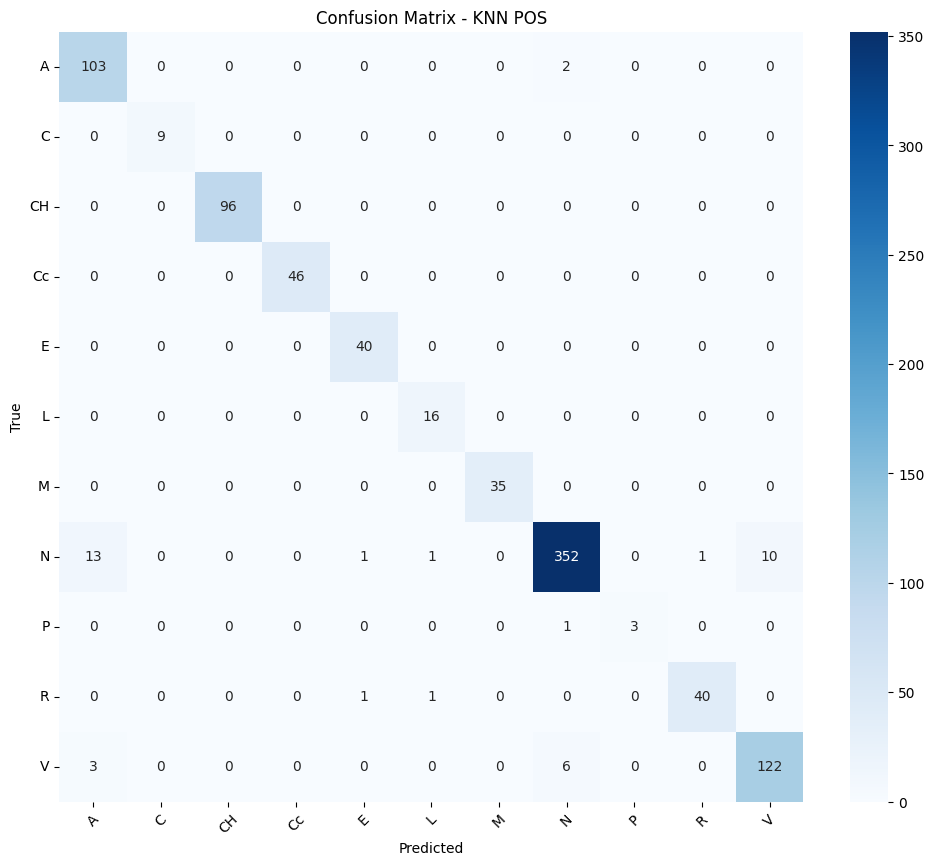

In [151]:
pos_labels = sorted(list(set(y_pos_knn)))

plot_confusion_matrix(
    y_pos_test,
    y_pos_pred,
    pos_labels,
    title="Confusion Matrix - KNN POS",
    figsize=(12, 10)
)

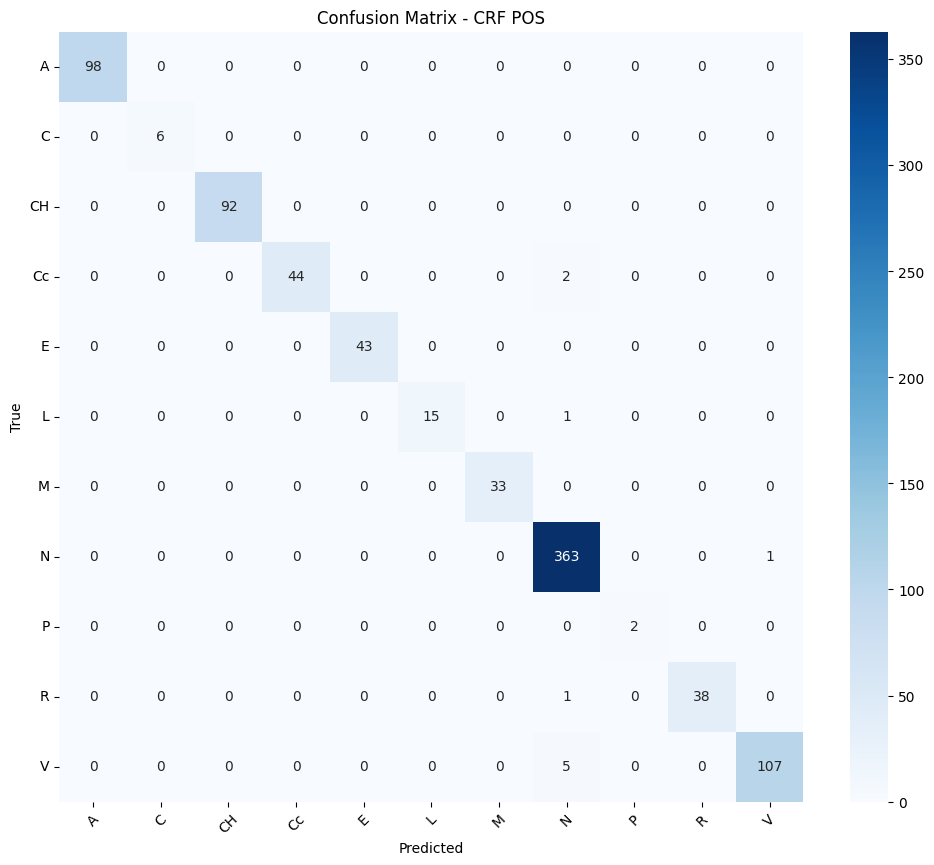

In [152]:
y_pos_crf_true_flat = [label for sent in y_pos_crf_test for label in sent]
y_pos_crf_pred_flat = [label for sent in y_pos_crf_pred for label in sent]

plot_confusion_matrix(
    y_pos_crf_true_flat,
    y_pos_crf_pred_flat,
    pos_labels,
    title="Confusion Matrix - CRF POS",
    figsize=(12, 10)
)

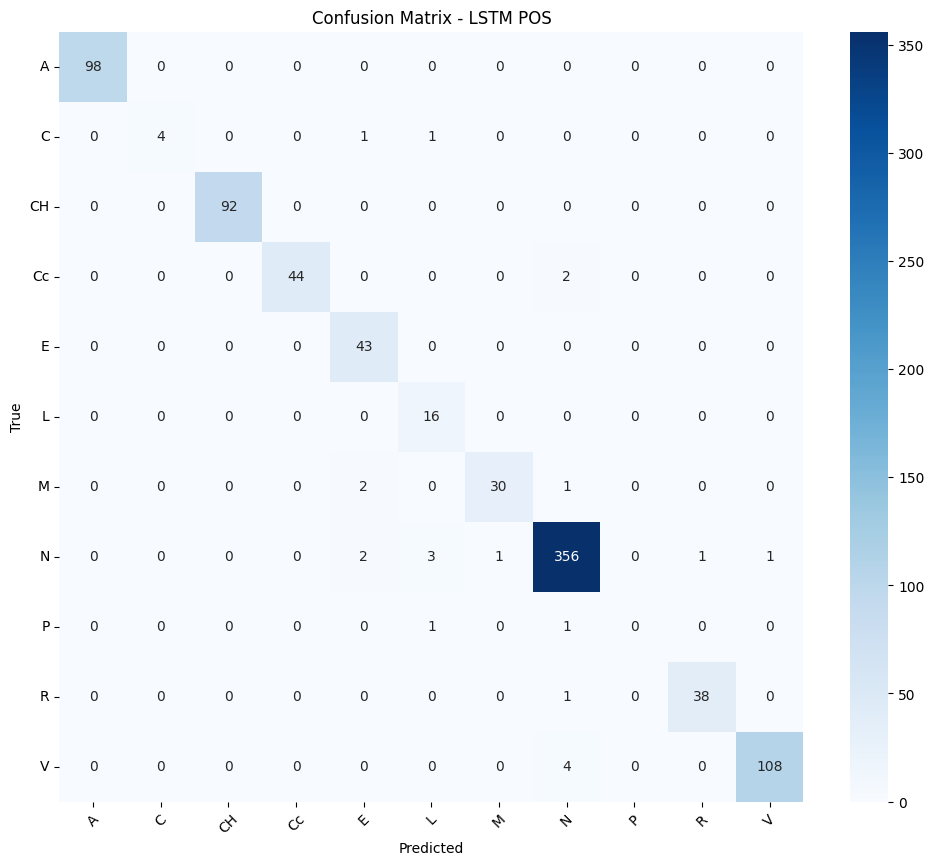

In [153]:
plot_confusion_matrix(
    lstm_pos_true,
    lstm_pos_pred,
    pos_labels,
    title="Confusion Matrix - LSTM POS",
    figsize=(12, 10)
)

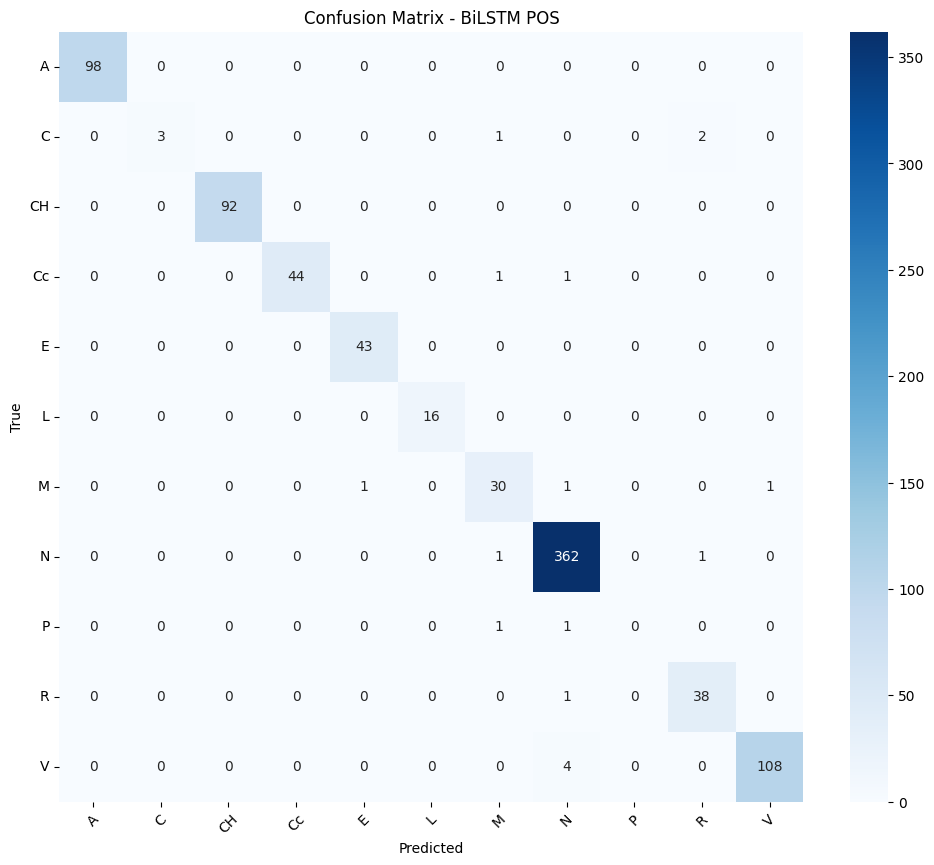

In [154]:
plot_confusion_matrix(
    bilstm_pos_true,
    bilstm_pos_pred,
    pos_labels,
    title="Confusion Matrix - BiLSTM POS",
    figsize=(12, 10)
)

### 6.2. Confusion matrix cho POS

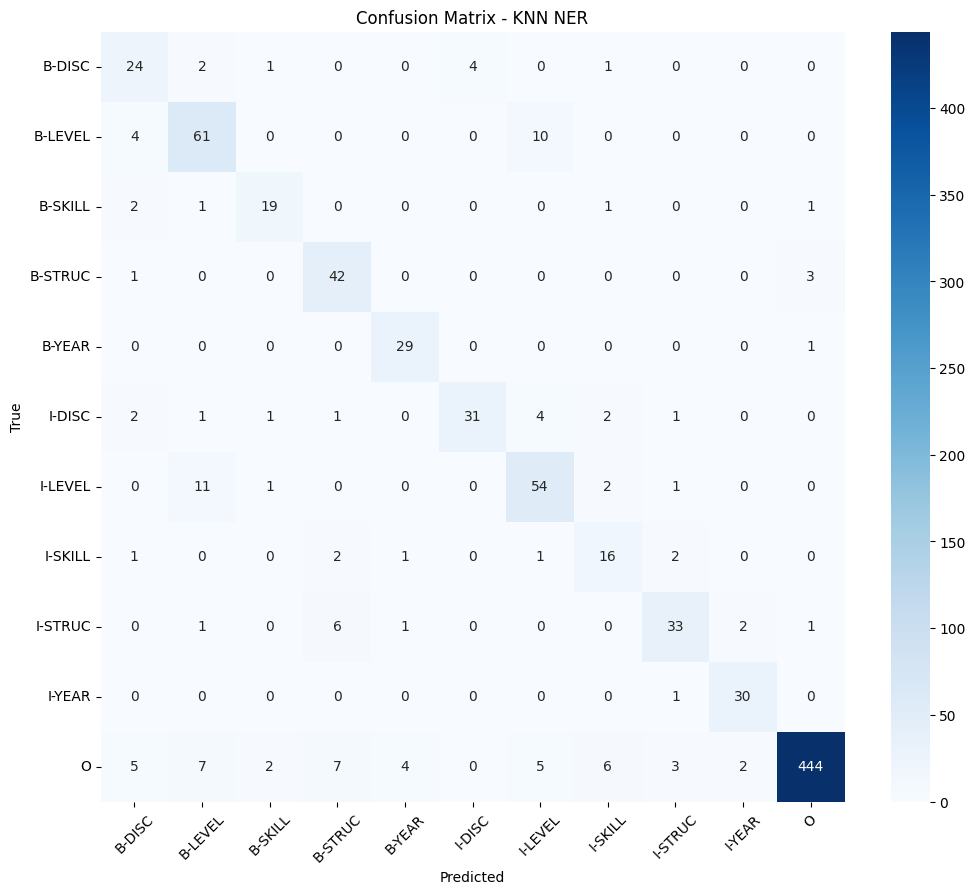

In [155]:
ner_labels = sorted(list(set(y_ner_knn)))

plot_confusion_matrix(
    y_ner_test,
    y_ner_pred,
    ner_labels,
    title="Confusion Matrix - KNN NER",
    figsize=(12, 10)
)

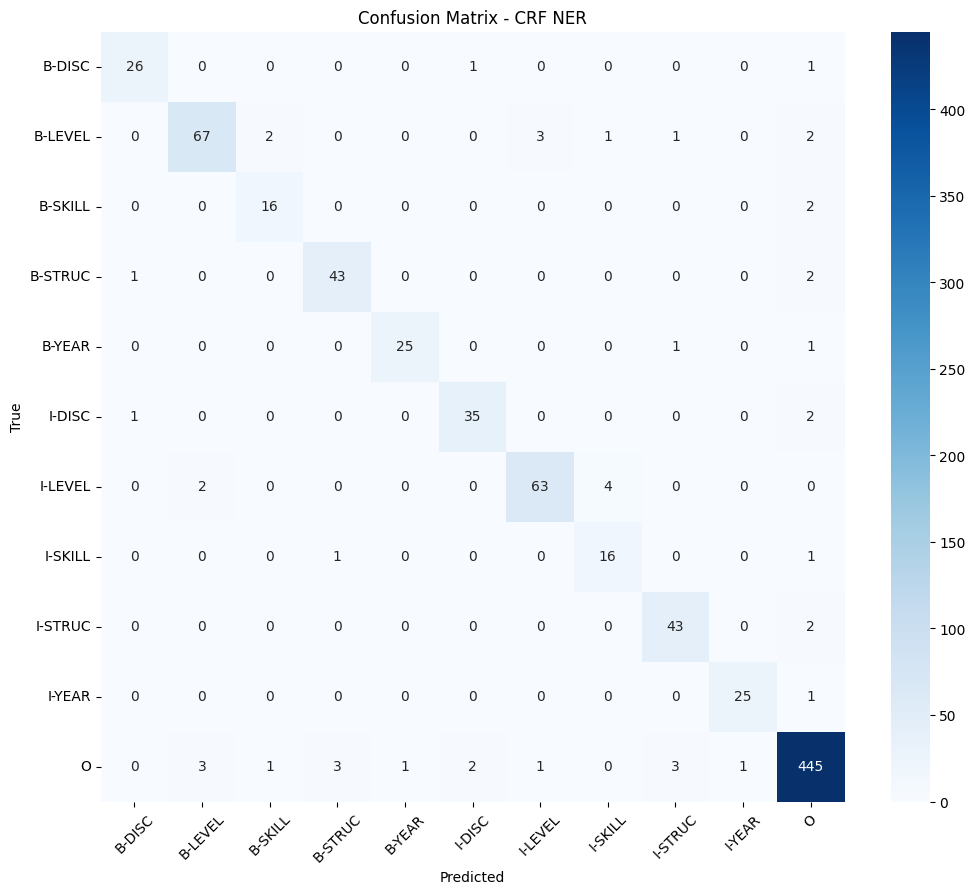

In [156]:
y_ner_crf_true_flat = [label for sent in y_ner_crf_test for label in sent]
y_ner_crf_pred_flat = [label for sent in y_ner_crf_pred for label in sent]

plot_confusion_matrix(
    y_ner_crf_true_flat,
    y_ner_crf_pred_flat,
    ner_labels,
    title="Confusion Matrix - CRF NER",
    figsize=(12, 10)
)

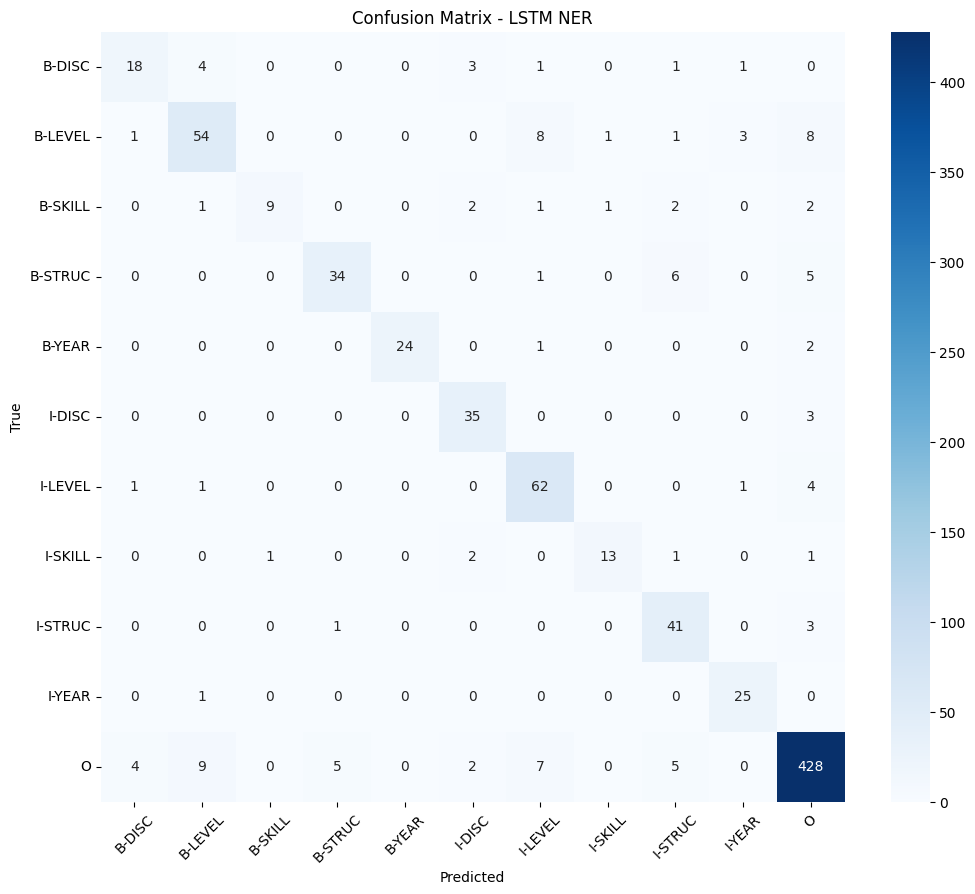

In [157]:
plot_confusion_matrix(
    lstm_ner_true,
    lstm_ner_pred,
    ner_labels,
    title="Confusion Matrix - LSTM NER",
    figsize=(12, 10)
)

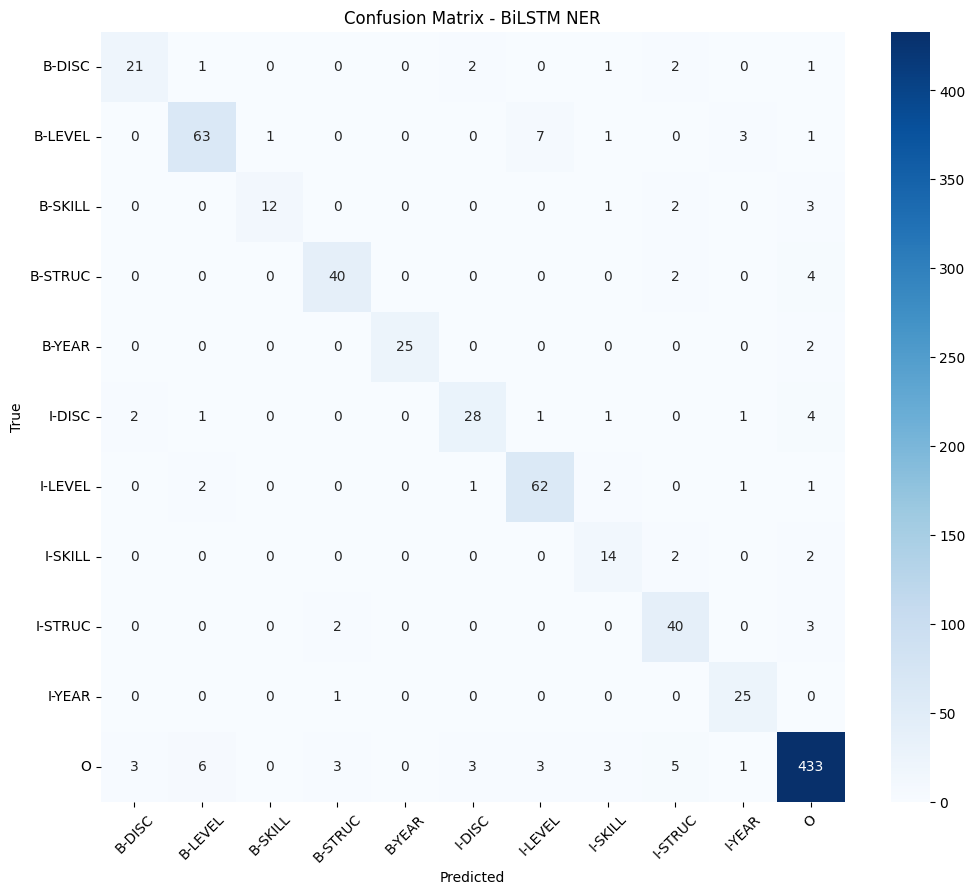

In [158]:
plot_confusion_matrix(
    bilstm_ner_true,
    bilstm_ner_pred,
    ner_labels,
    title="Confusion Matrix - BiLSTM NER",
    figsize=(12, 10)
)

## 7. Kết xuất kết quả

In [159]:
df_results.to_csv("model_results.csv", index=False)
print("Đã lưu file model_results.csv")

Đã lưu file model_results.csv


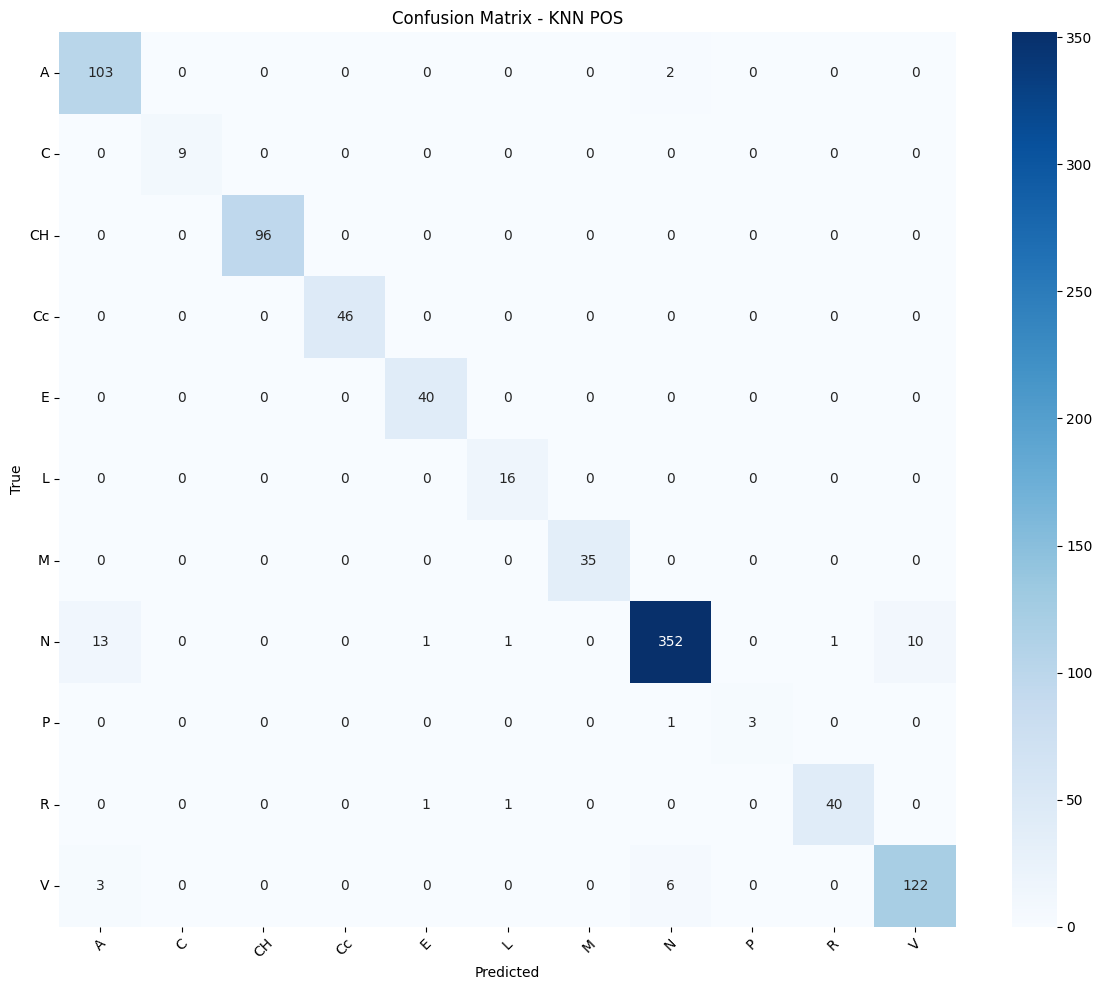

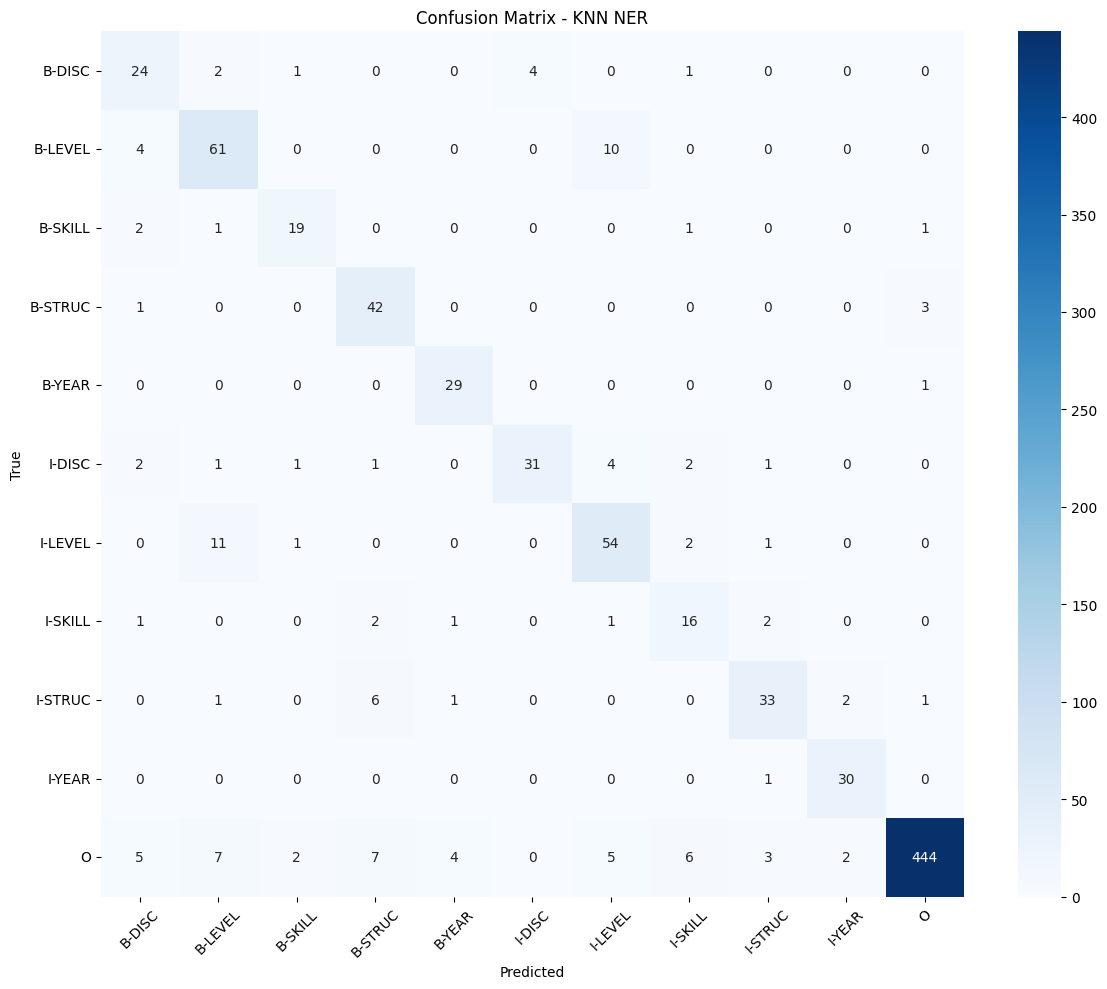

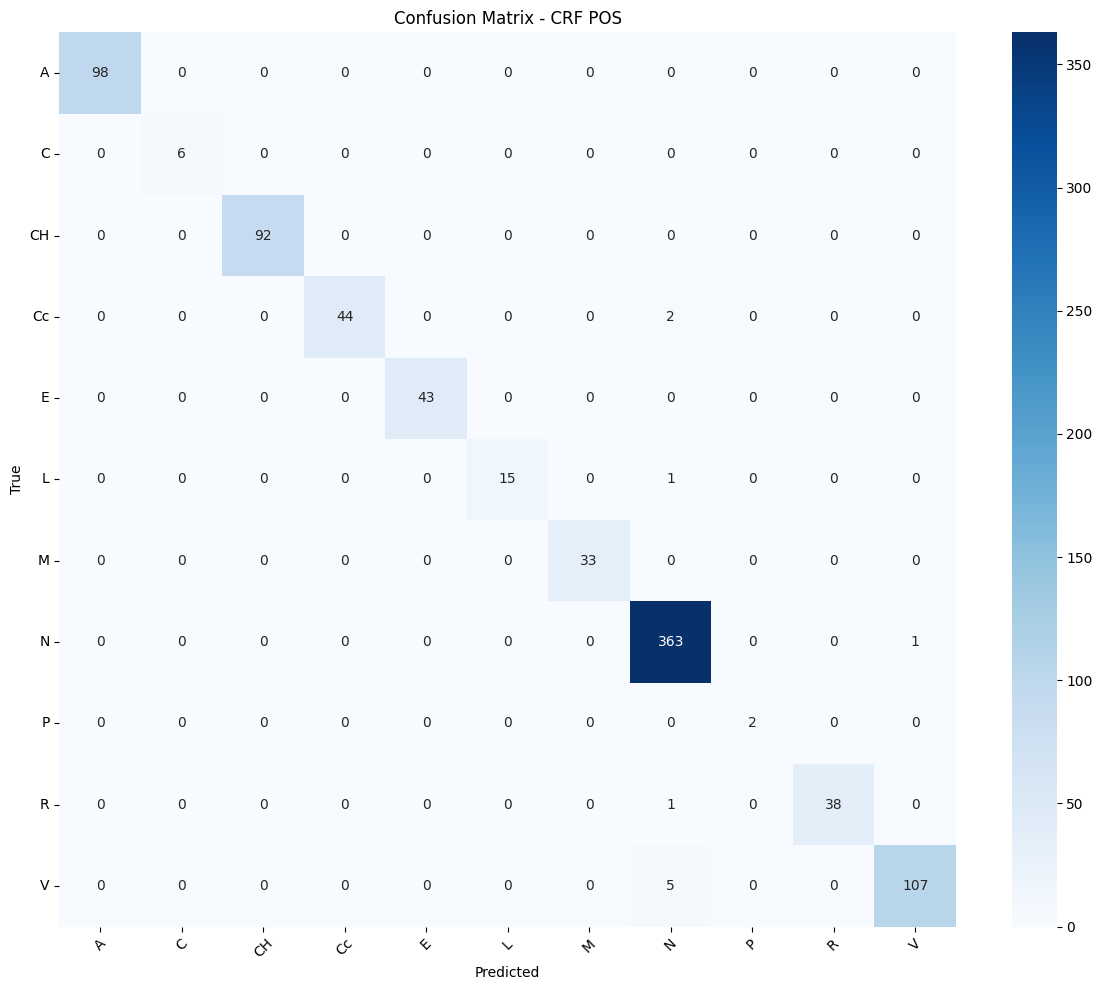

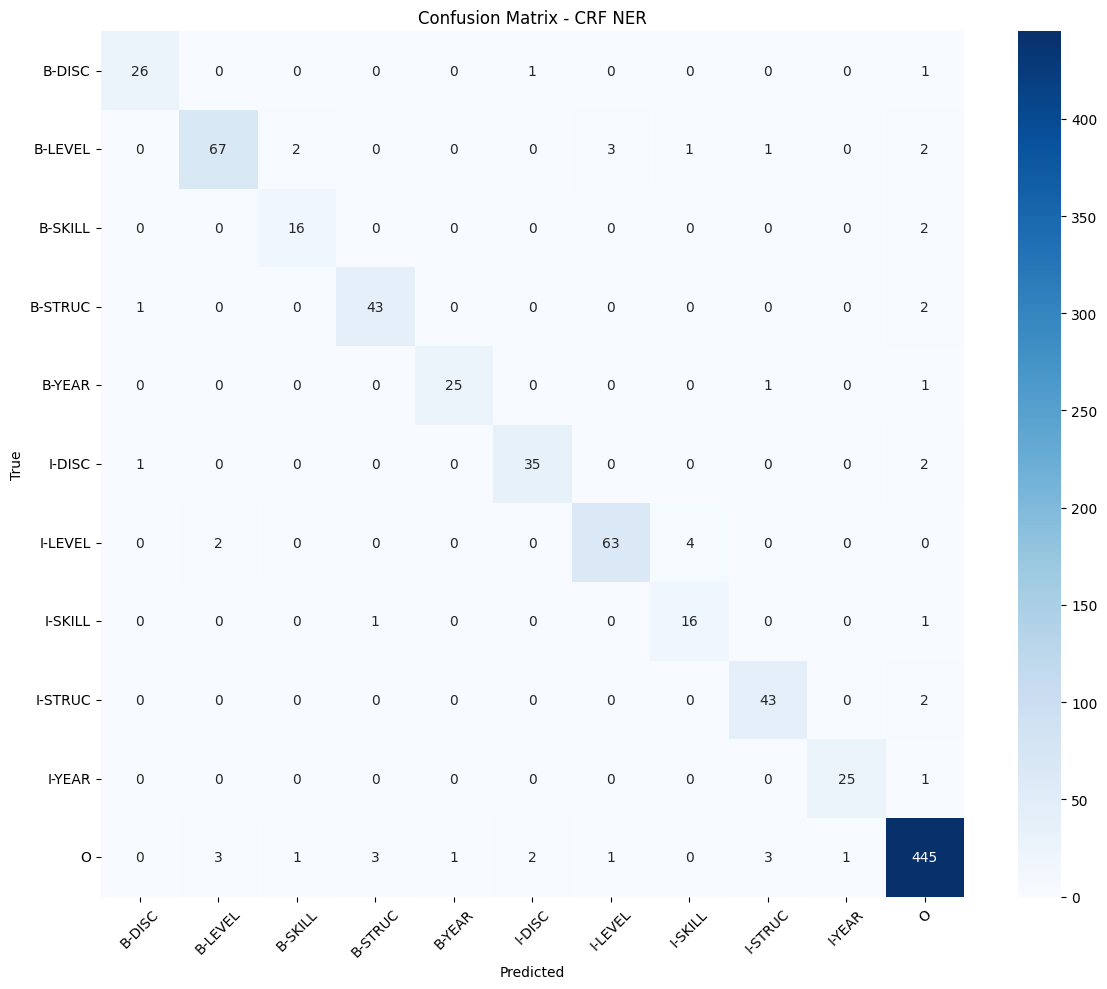

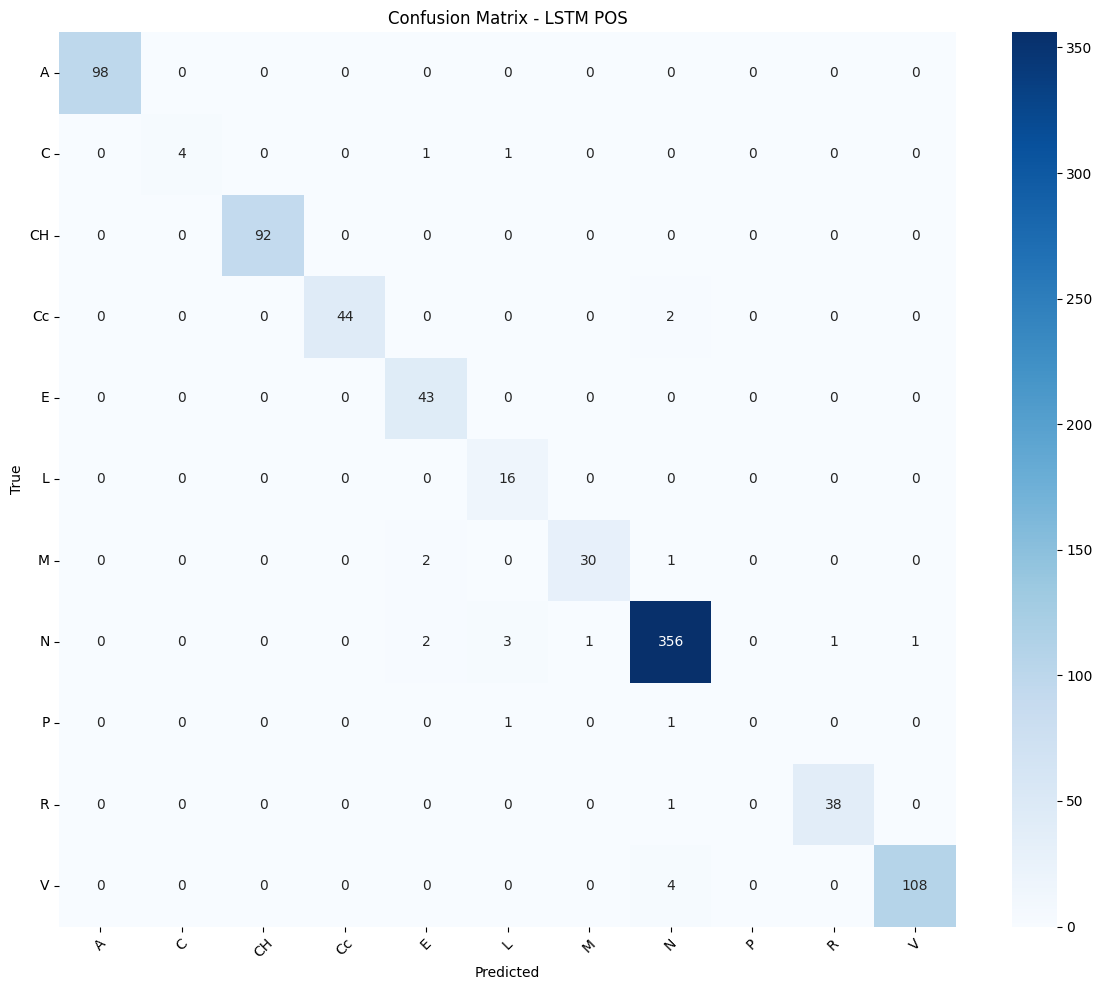

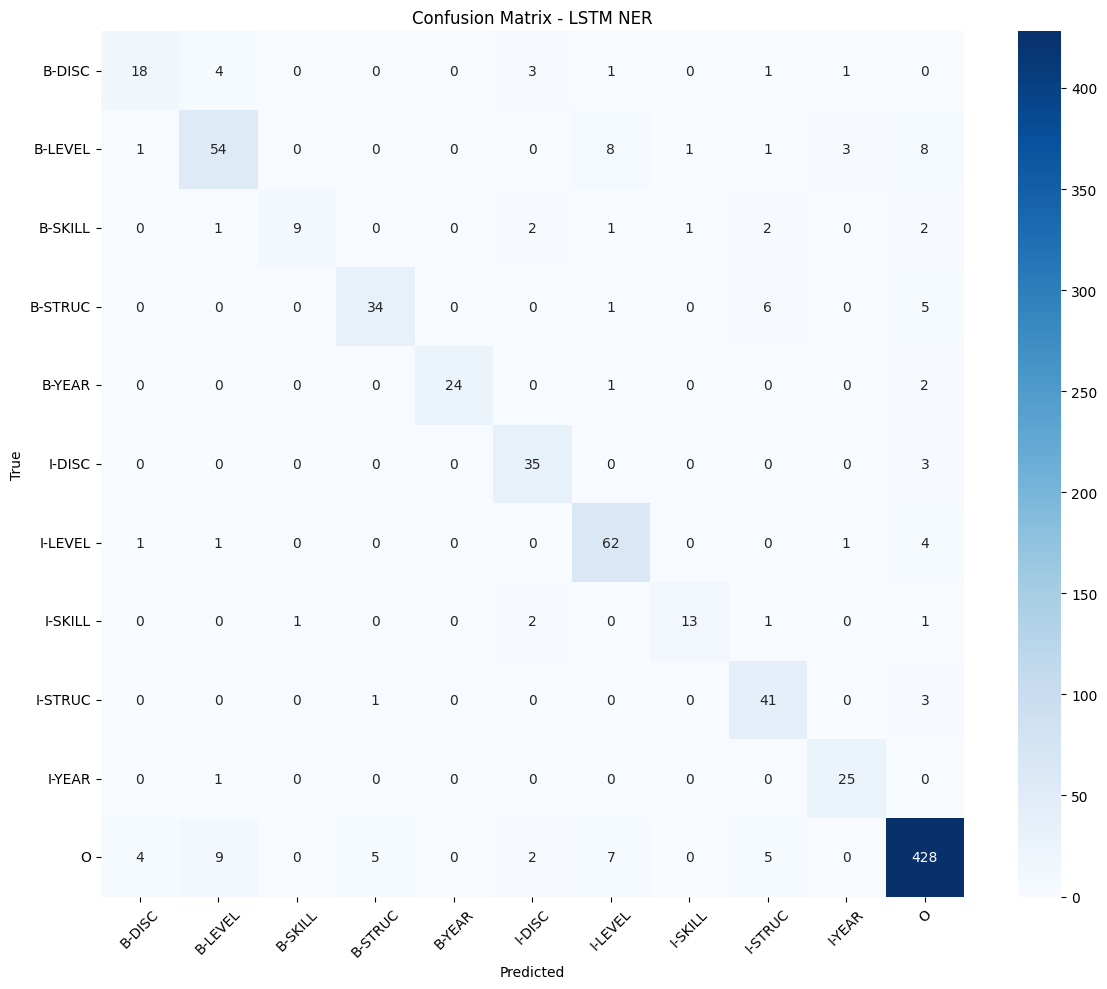

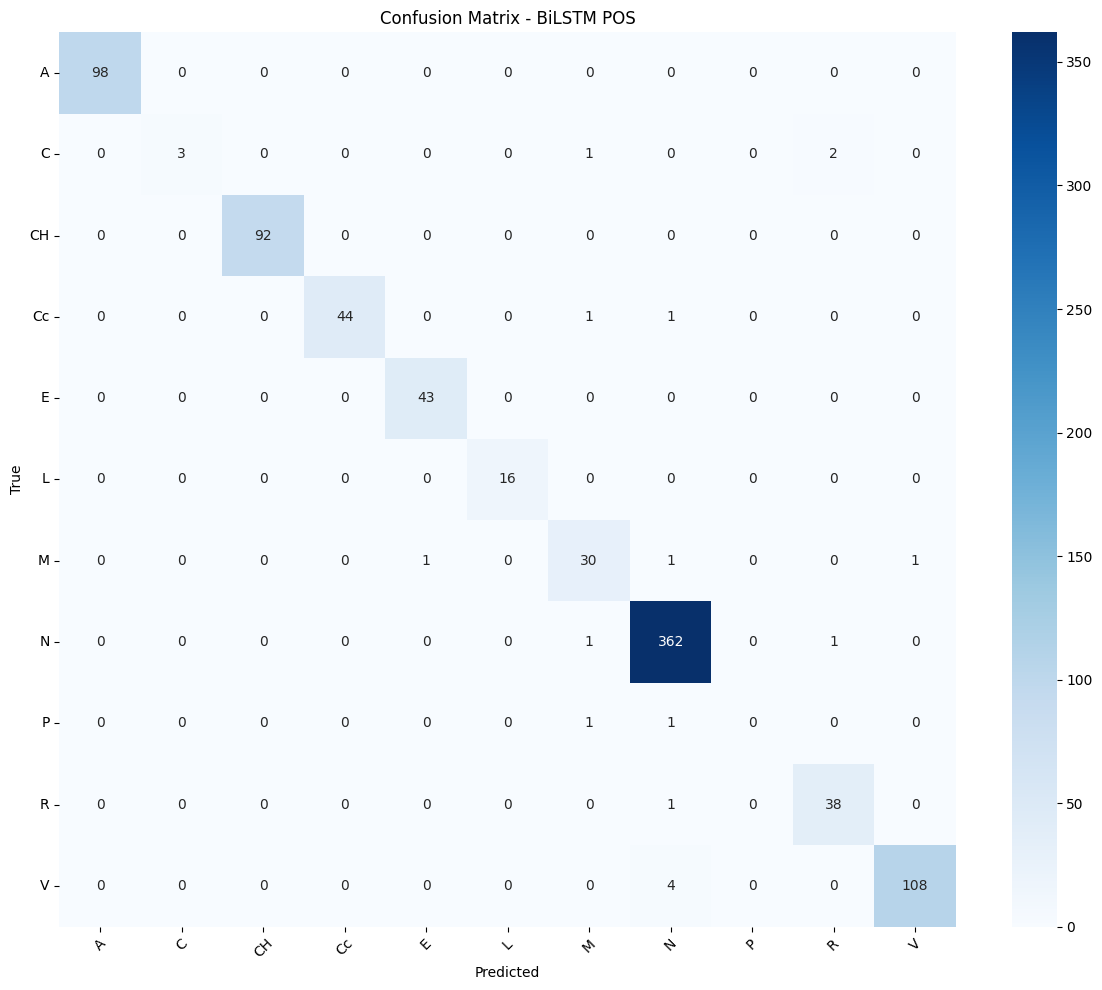

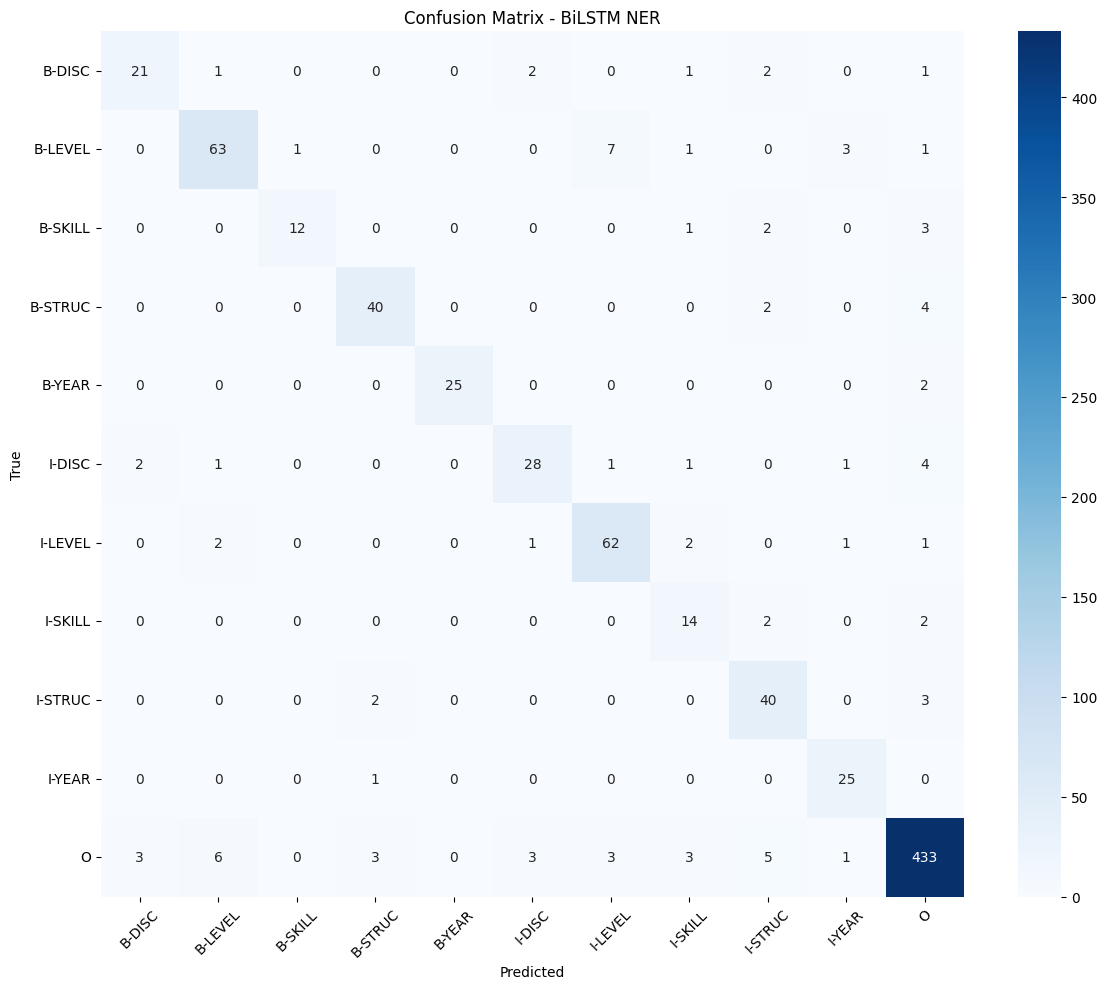

In [160]:
def save_confusion_matrix(y_true, y_pred, labels, title, filename, figsize=(10, 8)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

save_confusion_matrix(y_pos_test, y_pos_pred, pos_labels, "Confusion Matrix - KNN POS", "cm_knn_pos.png", figsize=(12, 10))
save_confusion_matrix(y_ner_test, y_ner_pred, ner_labels, "Confusion Matrix - KNN NER", "cm_knn_ner.png", figsize=(12, 10))
save_confusion_matrix(y_pos_crf_true_flat, y_pos_crf_pred_flat, pos_labels, "Confusion Matrix - CRF POS", "cm_crf_pos.png", figsize=(12, 10))
save_confusion_matrix(y_ner_crf_true_flat, y_ner_crf_pred_flat, ner_labels, "Confusion Matrix - CRF NER", "cm_crf_ner.png", figsize=(12, 10))
save_confusion_matrix(lstm_pos_true, lstm_pos_pred, pos_labels, "Confusion Matrix - LSTM POS", "cm_lstm_pos.png", figsize=(12, 10))
save_confusion_matrix(lstm_ner_true, lstm_ner_pred, ner_labels, "Confusion Matrix - LSTM NER", "cm_lstm_ner.png", figsize=(12, 10))
save_confusion_matrix(bilstm_pos_true, bilstm_pos_pred, pos_labels, "Confusion Matrix - BiLSTM POS", "cm_bilstm_pos.png", figsize=(12, 10))
save_confusion_matrix(bilstm_ner_true, bilstm_ner_pred, ner_labels, "Confusion Matrix - BiLSTM NER", "cm_bilstm_ner.png", figsize=(12, 10))

In [161]:
from google.colab import files

files.download("model_results.csv")
files.download("cm_knn_pos.png")
files.download("cm_knn_ner.png")
files.download("cm_crf_pos.png")
files.download("cm_crf_ner.png")
files.download("cm_lstm_pos.png")
files.download("cm_lstm_ner.png")
files.download("cm_bilstm_pos.png")
files.download("cm_bilstm_ner.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>